# 01 · Exploración inicial: ¿qué tenemos entre manos?

**Proyecto:** ¿Quién puede pagar hoy un crédito hipotecario UVA? · **Rol:** analista de crédito y negocio · **Cliente (ficticio):** Banco [EMPRESA]

Antes de limpiar, miramos los datos **tal como vienen**, con las tres preguntas de negocio del encuadre (`reports/00_encuadre.md`):

1. ¿Cuántos hogares inquilinos hay en CABA, Partidos del GBA y Gran Córdoba, y cuánto ganan? → tamaño del mercado potencial.
2. ¿Cómo viene el mercado de crédito (tasa y stock)? → contexto de la decisión.
3. ¿Qué tan confiables son las fuentes de precios? → cuánto podemos apoyarnos en ellas.

> **Alcance (decisión del Checkpoint 3):** Gran Rosario quedó fuera por tamaño de muestra; el GBA se analiza abierto por corredor en los notebooks siguientes.

Este notebook carga las fuentes crudas en DuckDB (`sql/01_staging.sql`) y explora. Las decisiones de limpieza se toman en el notebook 02.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import config
import viz
from formato import fmt_cantidad, fmt_hogares, fmt_mes, fmt_monto, fmt_pct, fmt_decimal
from run_sql import run_file

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30)

## 0. Carga cruda a staging (SQL)

In [2]:
import os
os.chdir(config.ROOT)
con = duckdb.connect(str(config.DB_PATH))
run_file(con, config.ROOT / "sql" / "01_staging.sql")


=== 01_staging.sql
  ok: INSTALL spatial;


  ok: LOAD spatial;


  ok: CREATE OR REPLACE TABLE stg_eph_hogar AS


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ok: CREATE OR REPLACE TABLE stg_eph_individual AS


...

  ok: CREATE OR REPLACE TABLE stg_gcba_2016 AS


  ok: CREATE OR REPLACE TABLE stg_gcba_2017 AS


  ok: CREATE OR REPLACE TABLE stg_gcba_2018 AS


  ok: CREATE OR REPLACE TABLE stg_gcba_2019 AS


  ok: CREATE OR REPLACE TABLE stg_gcba_2020 AS
  ok: CREATE OR REPLACE TABLE ref_precios_zonaprop AS
  ok: CREATE OR REPLACE TABLE ref_gba_partidos AS
  ok: CREATE OR REPLACE TABLE stg_rechazos_gcba AS

-- rechazos_gcba (5 filas)
                                       file_path  line        error_type  errores_registrados                                                     csv_line
0  data/raw/gcba/departamentos-en-venta-2007.csv  4951  TOO MANY COLUMNS                   14  \n;;;;;;;;;;;;;;;;4400;58.0;33000;569.0;0;0;;;;0;;;PARQU...
1  data/raw/gcba/departamentos-en-venta-2007.csv  4986  TOO MANY COLUMNS                   14  \n;;;;;;;;;;;;;;;;4200;49.0;36000;734.7;0;0;;;;0;;;VILLA...
2  data/raw/gcba/departamentos-en-venta-2007.csv  4988  TOO MANY COLUMNS                   14  \n;;;;;;;;;;;;;;;;4600;72.0;56900;790.3;4;20;CONTRAFRENT...
3  data/raw/gcba/departamentos-en-venta-2007.csv  4990  TOO MANY COLUMNS                   14  \n;;;;;;;;;;;;;;;;4700;62.0;40000;645.2;4;30;CONTRAFREN

## 1. EPH: hogares, tenencia e ingresos (datos crudos)

La EPH es una **encuesta**: cada hogar encuestado representa a muchos otros según su ponderador (`PONDERA` para hogares, `PONDIH` para ingresos). Explorar sin ponderar sobrerrepresenta a los aglomerados chicos, así que desde el inicio se pondera. Como se juntan 4 trimestres, cada peso se divide por 4: el resultado es el promedio del año.

In [3]:
tenencia = con.execute("""
    SELECT CASE AGLOMERADO WHEN '32' THEN 'CABA' WHEN '33' THEN 'Partidos del GBA' WHEN '13' THEN 'Gran Córdoba' END AS mercado,
           CASE WHEN II7 IN ('1','2') THEN 'Propietario' WHEN II7 = '3' THEN 'Inquilino' ELSE 'Otra situación' END AS tenencia,
           sum(CAST(PONDERA AS DOUBLE)) / 4 AS hogares
    FROM stg_eph_hogar
    WHERE AGLOMERADO IN ('32','33','13')
    GROUP BY ALL
""").df()
pivot = tenencia.pivot_table(index="mercado", columns="tenencia", values="hogares", aggfunc="sum")
pct = (pivot.div(pivot.sum(axis=1), axis=0) * 100).round(1)
pd.concat([pivot.map(fmt_cantidad), pct.add_suffix(" %")], axis=1).sort_values("Inquilino %", ascending=False)

tenencia,Inquilino,Otra situación,Propietario,Inquilino %,Otra situación %,Propietario %
mercado,,,,,,
CABA,432 mil,107 mil,720 mil,34.30,8.50,57.20
Gran Córdoba,181 mil,103 mil,321 mil,29.90,17.00,53.10
Partidos del GBA,631 mil,522 mil,3 millones,15.20,12.60,72.10


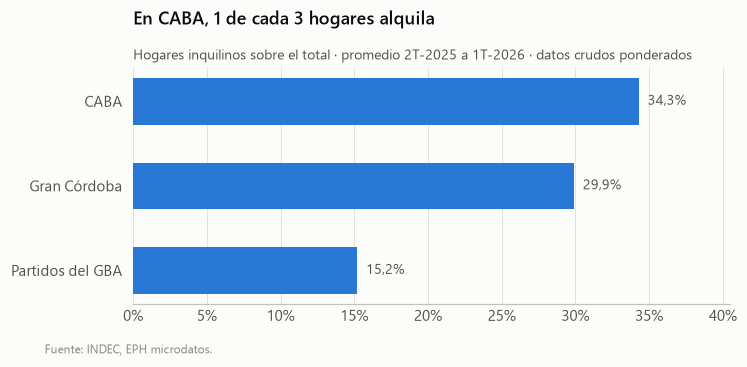

In [4]:
# % de hogares inquilinos por mercado: una sola serie, un solo color, ordenado por magnitud
s = pct["Inquilino"].sort_values()
fig, ax = plt.subplots(figsize=(7, 2.8))
bars = ax.barh(s.index, s.values, color=viz.BLUE, height=0.55)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.xaxis.set_major_formatter(viz.EJE_PCT)
for b, v in zip(bars, s.values):
    ax.text(v + 0.6, b.get_y() + b.get_height() / 2, fmt_pct(v), va="center", color=viz.INK_2, fontsize=9)
ax.set_xlim(0, s.max() * 1.18)
ax.set_title("En CABA, 1 de cada 3 hogares alquila")
viz.subtitle(ax, "Hogares inquilinos sobre el total · promedio 2T-2025 a 1T-2026 · datos crudos ponderados")
viz.source(fig, "INDEC, EPH microdatos.")
viz.save(fig, "01_pct_inquilinos_mercado")
plt.show()

**Primera señal de suciedad:** en el país, el 24,6% de los hogares encuestados no declara su ingreso (decil 12, `ITF = 0`). Si se promediara el ingreso "a lo bruto", esos ceros bajarían artificialmente el resultado:

In [5]:
itf = con.execute("""
    SELECT CASE WHEN II7 = '3' THEN 'Inquilino' WHEN II7 IN ('1','2') THEN 'Propietario' ELSE 'Otra' END AS tenencia,
           CAST(ITF AS DOUBLE) AS itf, CAST(PONDERA AS DOUBLE) AS pondera, CAST(PONDIH AS DOUBLE) AS pondih
    FROM stg_eph_hogar
    WHERE AGLOMERADO IN ('32','33','13') AND ANO4 = '2026' AND TRIMESTRE = '1'
""").df()

def wmedian(x, w):
    o = np.argsort(x); x, w = np.asarray(x)[o], np.asarray(w)[o]
    return x[np.searchsorted(np.cumsum(w), w.sum() / 2)]

pd.DataFrame({
    "Mediana ingenua (todas las filas, PONDERA)": itf.groupby("tenencia").apply(lambda d: wmedian(d.itf, d.pondera), include_groups=False),
    "Mediana correcta (PONDIH, sin no respuesta)": itf[itf.pondih > 0].groupby("tenencia").apply(lambda d: wmedian(d.itf, d.pondih), include_groups=False),
}).map(lambda v: fmt_monto(v))

,"Mediana ingenua (todas las filas, PONDERA)","Mediana correcta (PONDIH, sin no respuesta)"
tenencia,,
Inquilino,"$ 1,2 millones",$ 2 millones
Otra,$ 700 mil,"$ 1,4 millones"
Propietario,$ 578 mil,"$ 1,6 millones"


## 2. Mercado de crédito (BCRA): tasa y stock

Dos medidas de escala distinta → **dos gráficos**, nunca un doble eje (el doble eje inventa correlaciones).

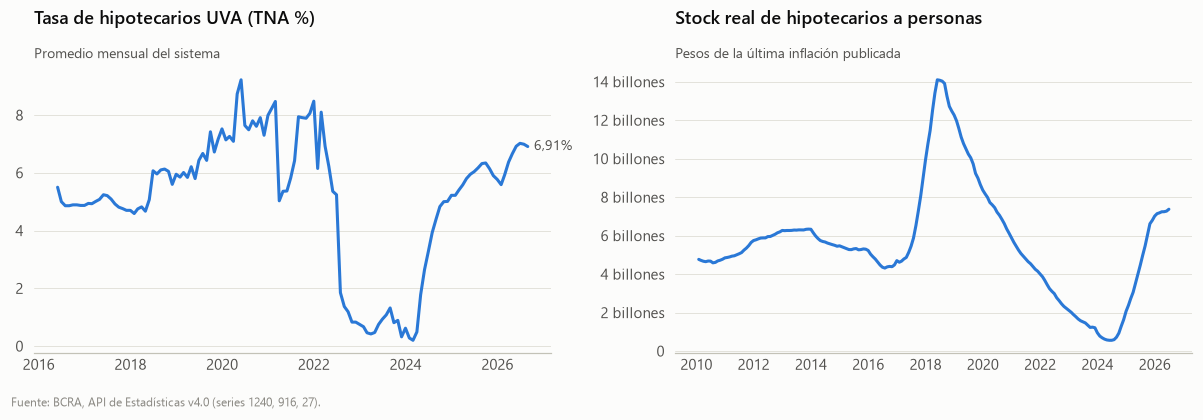

In [6]:
bcra = con.execute("""
    SELECT serie, CAST(fecha AS DATE) AS fecha, CAST(valor AS DOUBLE) AS valor FROM stg_bcra
    WHERE serie IN ('tasa_hipotecaria_uva', 'stock_hipotecarios_personas_humanas', 'inflacion_mensual')
""").df()
tasa = bcra[bcra.serie == "tasa_hipotecaria_uva"].set_index("fecha").valor.sort_index()
stock = bcra[bcra.serie == "stock_hipotecarios_personas_humanas"].set_index("fecha").valor.sort_index()
infl = bcra[bcra.serie == "inflacion_mensual"].set_index("fecha").valor.sort_index()
ipc = (1 + infl / 100).cumprod()
stock_real = stock * 1e6 * ipc.iloc[-1] / ipc.reindex(stock.index, method="nearest")   # la serie viene en millones de ARS

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
ax.plot(tasa.index, tasa.values, color=viz.BLUE)
ax.set_title("Tasa de hipotecarios UVA (TNA %)")
viz.subtitle(ax, "Promedio mensual del sistema")
ax.annotate(fmt_pct(tasa.iloc[-1], 2), (tasa.index[-1], tasa.iloc[-1]), xytext=(4, 0), textcoords="offset points", color=viz.INK_2, fontsize=9, va="center")
ax = axes[1]
s = stock_real[stock_real.index >= "2010-01-01"]
ax.plot(s.index, s.values, color=viz.BLUE)
ax.set_title("Stock real de hipotecarios a personas")
viz.subtitle(ax, "Pesos de la última inflación publicada")
ax.yaxis.set_major_formatter(viz.EJE_CANTIDAD)
viz.source(fig, "BCRA, API de Estadísticas v4.0 (series 1240, 916, 27).")
fig.tight_layout()
viz.save(fig, "01_bcra_tasa_stock_crudo")
plt.show()

## 3. Avisos de departamentos (GCBA 2001-2020): ¿qué tan confiables?

El mismo dataset cambió **cinco veces de esquema** en 20 años y el volumen de avisos salta de ~4 mil a más de 150 mil. Un salto así casi nunca es "más mercado": suele ser un cambio en cómo se recolectan los datos (portales, capturas mensuales repetidas).

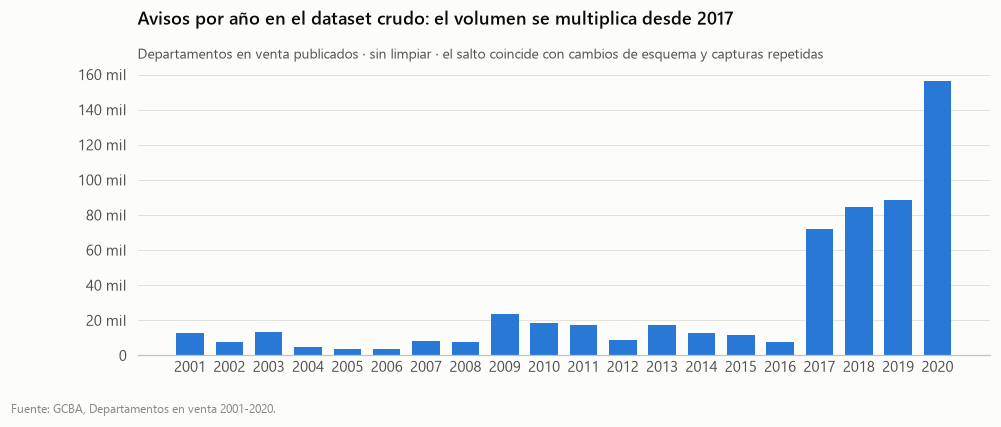

In [7]:
gcba = con.execute(r"""
    SELECT CAST(regexp_extract(filename, '(\d{4})') AS INT) AS anio, count(*) AS n FROM stg_gcba_2001_2014 GROUP BY 1
    UNION ALL SELECT 2015, count(*) FROM stg_gcba_2015
    UNION ALL SELECT 2016, count(*) FROM stg_gcba_2016
    UNION ALL SELECT 2017, count(*) FROM stg_gcba_2017
    UNION ALL SELECT 2018, count(*) FROM stg_gcba_2018
    UNION ALL SELECT 2019, count(*) FROM stg_gcba_2019
    UNION ALL SELECT 2020, count(*) FROM stg_gcba_2020
""").df().sort_values("anio")
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(gcba.anio.astype(str), gcba.n, color=viz.BLUE, width=0.7)
ax.yaxis.set_major_formatter(viz.EJE_CANTIDAD)
ax.set_title("Avisos por año en el dataset crudo: el volumen se multiplica desde 2017")
viz.subtitle(ax, "Departamentos en venta publicados · sin limpiar · el salto coincide con cambios de esquema y capturas repetidas")
viz.source(fig, "GCBA, Departamentos en venta 2001-2020.")
viz.save(fig, "01_gcba_avisos_crudos_por_anio")
plt.show()

## Qué nos llevamos de la exploración

| Observación | Implicancia para la limpieza (notebook 02) |
|---|---|
| 25% de hogares sin ingreso declarado (decil 12) | Usar `PONDIH` para ingresos; nunca promediar el ITF crudo. Probar además una imputación como control |
| Los hogares se repiten entre trimestres (panel rotativo) | Apilar los 4 trimestres con pesos / 4 y tratar las visitas de un mismo hogar como un conglomerado |
| Ingresos de trimestres distintos en pesos corrientes | Llevar todo a pesos de agosto de 2026 con el IPC |
| Tasa UVA en alza en 2026; stock real creciendo desde 2024 | Contexto de mercado (se analiza con series limpias) |
| GCBA: 5 esquemas, volumen que explota desde 2017 | Armonizar columnas, deduplicar, filtrar tipos y valores extremos antes de usar precios |

In [8]:
con.close()